In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='str')


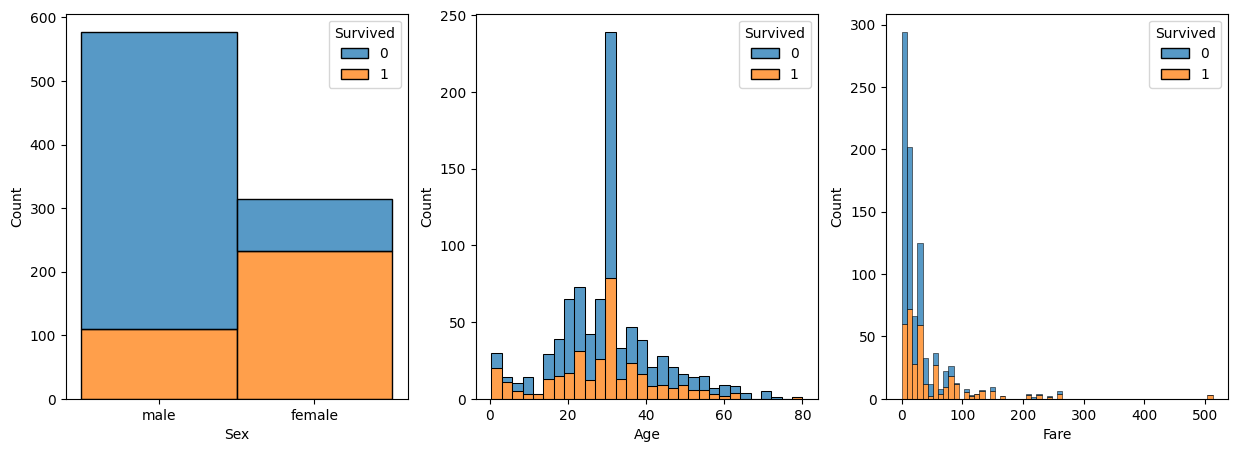

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,C85,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,C85,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,C123,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,C50,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B42,S


In [2]:
df = pd.read_csv("data/003-titanic.csv").set_index("PassengerId")

df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Cabin"] = df["Cabin"].ffill()
df["Cabin"] = df["Cabin"].bfill()
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df.columns)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(data=df, x="Sex", multiple="stack", hue="Survived", ax=axes[0])
sns.histplot(data=df, x="Age", multiple="stack", hue="Survived", ax=axes[1])
sns.histplot(data=df, x="Fare", multiple="stack", hue="Survived", ax=axes[2])

plt.show()

df

In [3]:
X_raw = df[["Sex", "Age", "Fare", "Pclass"]].to_numpy()

le = LabelEncoder()
le.fit(X_raw[:, 0])
X_raw[:, 0] = le.fit_transform(X_raw[:, 0])
X_raw = X_raw.astype(float)

scaler = StandardScaler()
scaler.fit(X_raw)
X = scaler.transform(X_raw)
y = df["Survived"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=67)

In [4]:
model = LogisticRegression(max_iter=50, C=4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.8004484304932735


In [5]:
model = DecisionTreeClassifier(max_depth=5, random_state=67)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.8161434977578476


In [6]:
model = XGBClassifier(n_estimators=12, random_state=67)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.820627802690583


In [7]:
# GridSearchCV on DecisionTreeClassifier

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "max_depth": range(1, 21, 1),
        "random_state": [67],
    },
    cv=10,
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Accuracy of best model: {accuracy_score(y_test, best_model.predict(X_test)):.3f}")

Accuracy of best model: 0.809


In [8]:
# GridSearchCV on XGBoost
param_grid = {
    "n_estimators": range(1, 21, 1),
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(),
    param_grid=param_grid
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Accuracy of best model: {accuracy_score(y_test, best_model.predict(X_test)):.3f}")

Accuracy of best model: 0.821
